# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [1]:
import os
import time

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 200)

import pickle

from sklearn import model_selection, preprocessing

import importlib
import html_tools
import funcs

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-05-26 07:08:14.449045: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-26 07:08:14.679038: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Chargement des données

In [2]:
path_results = 'data/results/'
path_models = 'data/models/'

path_save = 'data/cleaned/'
df = pd.read_pickle(path_save + 'data.pickle')

In [3]:
with open(path_save + 'dico_tags', 'rb') as file:
    tags = pickle.load(file)

# Essais

In [4]:
df.columns

Index(['Title_clean', 'Title_processed', 'Body_clean', 'Body_processed',
       'Tags'],
      dtype='object')

In [5]:
tmp = tags['most used'].index.tolist()[0]
y_tag = funcs.compute_y_tag(df['Tags'], tmp).astype(int)

df_tags = funcs.multi_label_binarize(df['Tags'],
                                     tags['most used'].index.tolist())
display(df_tags)

x_train, x_test, y_train, y_test = model_selection.train_test_split(
                                                    df[['Title_clean',
                                                        'Body_clean',
                                                        'Title_processed',
                                                        'Body_processed'
                                                        ]],
                                                    df_tags, test_size=0.5,
                                                    random_state=7)
print('train:')
print('x:', x_train.shape)
print('y:', y_train.shape)
print('\ntest:')
print('x:', x_test.shape)
print('y:', y_test.shape)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
173250,0,0,1,0,0,0,0,0,0,0
173251,0,1,0,0,0,0,0,0,0,0
173252,0,0,0,0,1,0,0,0,0,0
173253,1,0,0,0,0,0,0,0,0,0


train:
x: (86627, 4)
y: (86627, 10)

test:
x: (86628, 4)
y: (86628, 10)


In [6]:
features = ['Title_processed', 'Body_processed']
model = 'LogisticRegression'

In [7]:
vectorised = funcs.Vectorised()
vectorised.initialize_data('tfidf',
                           funcs.concat_str_features(x_train, features),
                           y_train,
                           min_df=100, max_df=0.95, max_features=1000
                           )
vectorised.set('test', funcs.concat_str_features(x_test, features))
prediction_tags = vectorised.get_prediction_tags()

vocaublary length: 1000


## Méthode non supervisée

In [8]:
tmp = funcs.Vectorised()
tmp.initialize_data('countvectorizer',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    min_df=100, max_df=0.95, max_features=1000
                    )
# vectorised.set('test', funcs.concat_str_features(x_test, features))

vocaublary length: 1000


x: (86627, 1000)
vocabulary: 1000

x sum axis=0: (1000,)
most used terms (decreasing order)
['use' 'class' 'return' 'get' 'new' 'code' 'public' 'file' 'error'
 'string' 'android' 'function' 'int' 'work' 'try' '124' 'application'
 'like' 'value' 'name' 'would' 'type' 'data' 'method' 'void' 'object'
 'import' 'call' 'run' 'find' 'var' 'want' 'way' 'one' 'std' 'set' 'id'
 'follow' 'create' 'true' 'time' 'test' 'line' 'need' 'problem' 'null'
 'make' 'add' 'result' 'user' 'cannot' 'array' 'know' 'private' 'example'
 'version' 'see' 'also' 'change' 'could' 'static' 'question' 'list'
 'false' 'python' '10' 'look' 'const' 'project' 'something' 'seem' 'div'
 'exception' 'include' 'update' 'case' 'java' 'view' 'start' 'first'
 'image' 'main' 'text' 'number' 'show' 'else' 'message' 'server' 'give'
 'write' 'request' 'print' 'edit' 'however' 'build' 'item' 'key' 'thread'
 'issue' 'script' 'let' 'two' 'override' 'go' 'check' '00' 'output'
 'element' 'read' 'page' 'solution' 'help' 'load' 'compile' 

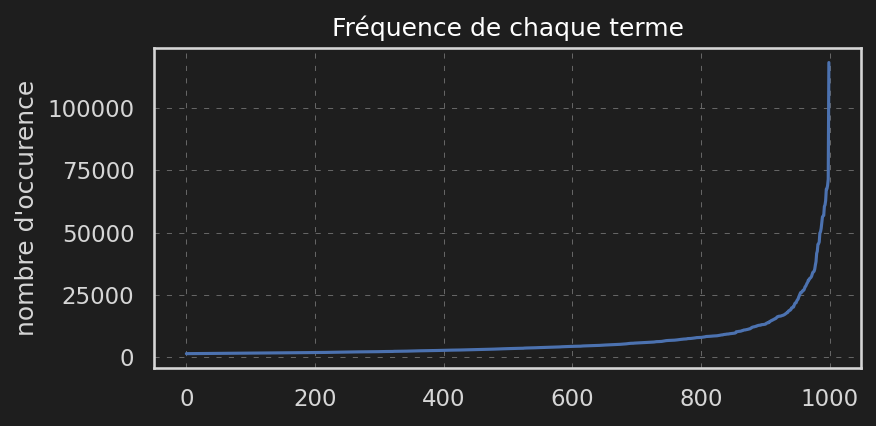

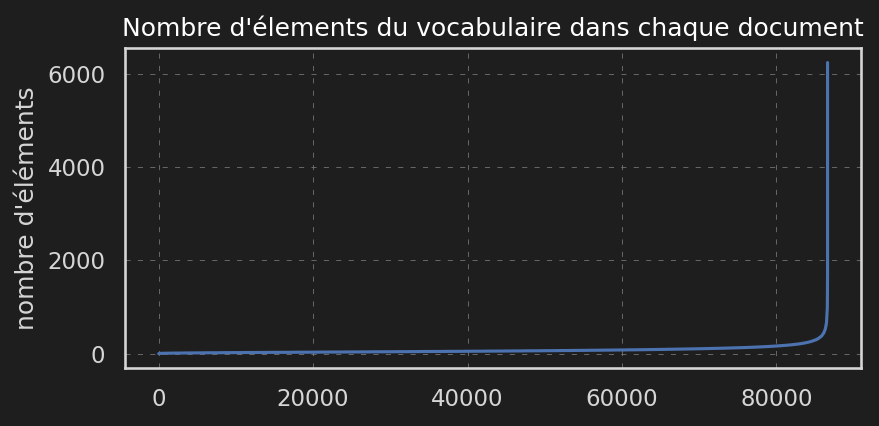

In [9]:
importlib.reload(funcs)
funcs.plot_sum_vectorizer(funcs.concat_str_features(x_train, features),
                          tmp)

In [10]:
importlib.reload(funcs)
vis = funcs.init_lda(vectorised, len(tags['most used']))

LDA: 10 topics
iteration: 1 of max_iter: 10
iteration: 2 of max_iter: 10
iteration: 3 of max_iter: 10
iteration: 4 of max_iter: 10
iteration: 5 of max_iter: 10
iteration: 6 of max_iter: 10
iteration: 7 of max_iter: 10
iteration: 8 of max_iter: 10
iteration: 9 of max_iter: 10
iteration: 10 of max_iter: 10


In [11]:
funcs.show_lda_vis(vis)

Les résultats ne semblent pas exploitable. Le terme "python" apparaît, lié aux topics 1,2 et 8.
L'utilisation pour prédire les tags semblent inappropriée.

## PCA

In [12]:
vectorised.pca_fit_on_train(1000)

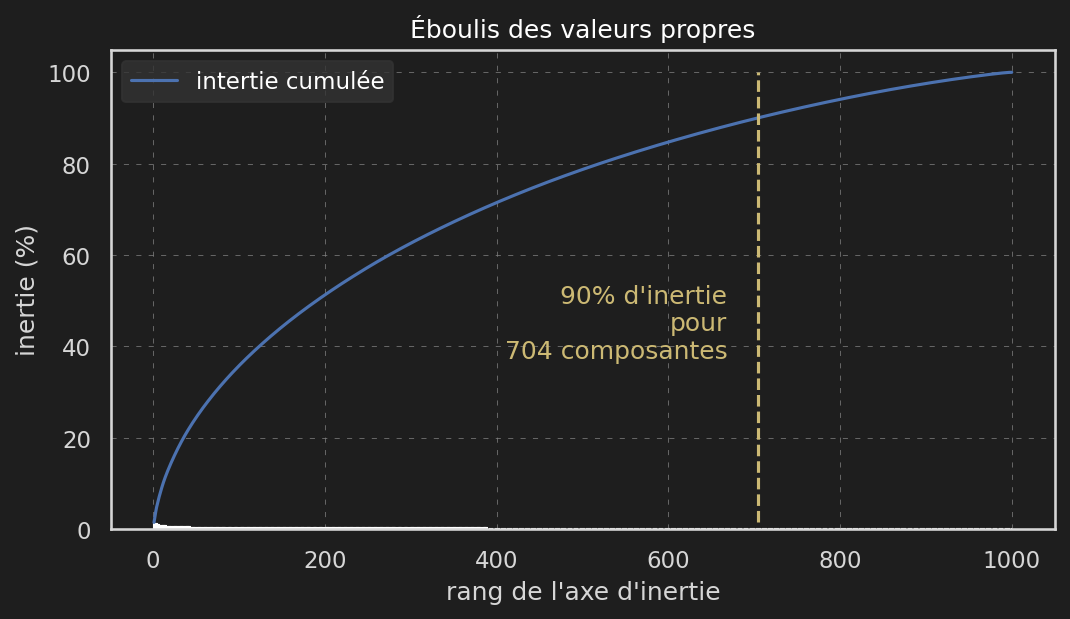

In [13]:
funcs.plot_ebouli_pca(vectorised.pca, 90, 'ebouli_tfidf')

In [14]:
vectorised.train_classifier(model, b_scale_x=True, n_pca_components=0)
y_pred = vectorised.predict('train')
y_true = y_train.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.format(precision=2).set_caption('without PCA'))

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.70,97.10,90.86,96.01,92.74,85.90,91.50,89.47,94.74,91.36
recall,81.18,90.06,71.94,87.14,83.39,71.21,75.50,76.39,80.60,71.75
specificity,98.39,99.55,98.65,99.52,98.86,97.98,99.84,99.36,99.67,99.79
F1 score,85.68,93.45,80.30,91.36,87.82,77.87,82.73,82.41,87.10,80.38


In [15]:
vectorised.train_classifier(model, b_scale_x=True, n_pca_components=700)
y_pred = vectorised.predict('train')
prediction_tags = vectorised.get_prediction_tags()
y_true = y_train.values

df_res_pca = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.format(precision=2).set_caption('with PCA'))

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.70,97.10,90.86,96.01,92.74,85.90,91.50,89.47,94.74,91.36
recall,81.18,90.06,71.94,87.14,83.39,71.21,75.50,76.39,80.60,71.75
specificity,98.39,99.55,98.65,99.52,98.86,97.98,99.84,99.36,99.67,99.79
F1 score,85.68,93.45,80.30,91.36,87.82,77.87,82.73,82.41,87.10,80.38


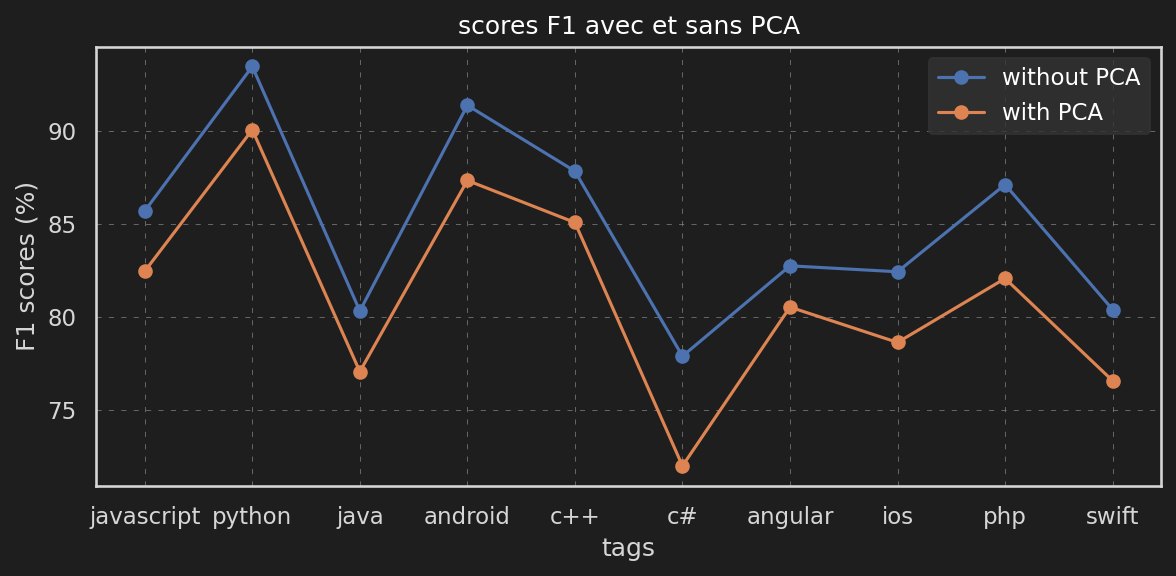

In [16]:
results = {'without PCA': df_res.iloc[-1],
           'with PCA': df_res_pca.iloc[-1]}

funcs.plot_f1_scores(results, prediction_tags, 'avec et sans PCA', 'PCA')

Pour l'essai effectué, la PCA dégrade les résultats.

## Convergence des classifieurs

In [17]:
vectorised = funcs.Vectorised()
vectorised.initialize_data('tfidf',
                           funcs.concat_str_features(x_train, features),
                           y_train,
                           min_df=100, max_df=0.95, max_features=300
                           )
vectorised.set('test', funcs.concat_str_features(x_test, features))

vocaublary length: 300


In [18]:
results = {}
def test_model(vectorised, model, b_scale_x):
    tmp = funcs.Vectorised()
    tmp.copy_data_from_vetorizer(vectorised)

    t0 = time.time()
    tmp.train_classifier(model, b_scale_x=b_scale_x)
    print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

    y_pred = tmp.predict('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()

    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    # display(df_res)
    display(df_res.style.format(precision=2).set_caption(model))
    results[model] = df_res.iloc[-1, :]

In [19]:
vectorised.x['train']

<86627x300 sparse matrix of type '<class 'numpy.float64'>'
	with 2298472 stored elements in Compressed Sparse Row format>

In [20]:
test_model(vectorised, 'Dummy', b_scale_x=False)

elapsed time: 0.33 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
recall,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
specificity,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
F1 score,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [12]:
# ne converge pas
# test_model(vectorised, 'svc')

In [21]:
test_model(vectorised, 'Logistic Regression', b_scale_x=False)

elapsed time: 8.75 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.88,95.44,87.66,96.37,90.08,75.34,73.52,87.97,94.53,83.23
recall,69.62,79.34,58.10,77.05,72.32,44.64,25.69,54.03,63.79,32.60
specificity,98.17,99.36,98.47,99.61,98.65,97.46,99.79,99.46,99.73,99.80
F1 score,77.69,86.65,69.88,85.64,80.23,56.06,38.07,66.95,76.18,46.85


In [22]:
test_model(vectorised, 'Logistic Regression', b_scale_x=True)

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


elapsed time: 23.66 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.24,94.92,86.82,95.44,88.99,74.09,72.31,86.66,92.55,81.84
recall,71.68,81.81,59.80,79.63,74.21,47.97,30.23,57.90,67.71,37.18
specificity,98.01,99.26,98.30,99.48,98.44,97.08,99.74,99.35,99.60,99.75
F1 score,78.70,87.88,70.82,86.82,80.93,58.23,42.64,69.42,78.20,51.13


In [23]:
test_model(vectorised, 'SDG Classifier', b_scale_x=True)

elapsed time: 16.51 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,82.89,92.37,84.34,94.31,88.30,67.80,51.62,87.11,91.96,83.03
recall,72.80,81.75,57.89,79.38,71.43,48.23,37.79,54.27,66.98,34.25
specificity,97.14,98.86,97.99,99.35,98.40,96.02,99.21,99.41,99.57,99.79
F1 score,77.52,86.73,68.66,86.20,78.98,56.36,43.64,66.88,77.50,48.49


In [24]:
test_model(vectorised, 'Multinomial NB', b_scale_x=False)

elapsed time: 0.56 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,89.73,98.83,91.23,98.44,95.29,94.14,64.71,96.23,98.40,100.00
recall,39.39,47.54,20.87,47.00,54.98,1.88,0.58,13.40,20.81,0.27
specificity,99.14,99.91,99.62,99.90,99.54,99.98,99.99,99.96,99.98,100.00
F1 score,54.75,64.20,33.97,63.63,69.73,3.68,1.15,23.53,34.36,0.55


In [25]:
test_model(vectorised, 'Perceptron', b_scale_x=True)

elapsed time: 1.28 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,63.91,81.60,62.55,79.78,72.78,49.89,30.25,60.84,65.62,51.75
recall,63.71,80.52,61.50,77.71,75.66,49.02,40.59,59.86,69.26,34.01
specificity,93.16,96.95,93.11,97.33,95.20,91.44,97.91,97.18,97.35,99.04
F1 score,63.81,81.05,62.02,78.73,74.20,49.45,34.66,60.35,67.39,41.05


In [26]:
test_model(vectorised, 'Passive Aggressive Classifier', b_scale_x=True)

elapsed time: 1.50 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,70.79,79.50,58.32,77.55,63.92,48.41,36.24,63.35,61.25,36.38
recall,69.95,79.03,64.50,77.14,76.02,43.16,44.13,57.74,69.26,33.42
specificity,94.51,96.58,91.37,96.97,92.72,92.00,98.27,97.56,96.79,98.22
F1 score,70.37,79.27,61.26,77.34,69.45,45.64,39.80,60.41,65.01,34.84


In [27]:
filename = 'different_models'
if True:
    with open(path_results + filename + '.pickle', 'wb') as file:
        pickle.dump(results, file)
else:
    with open(path_results + filename + '.pickle', 'rb') as file:
        results = pickle.load(file)

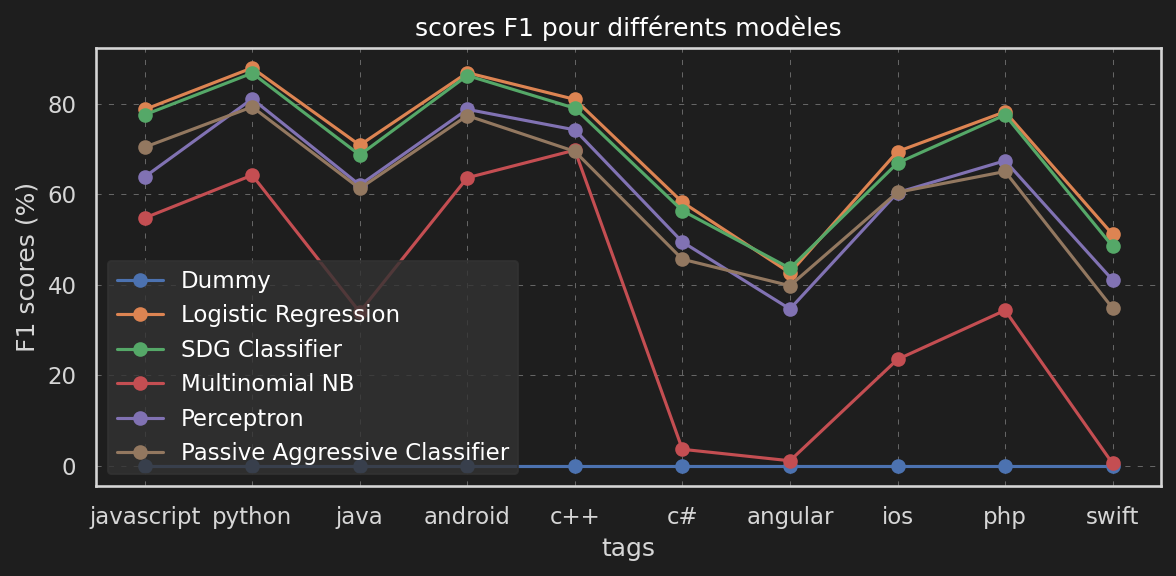

In [28]:
funcs.plot_f1_scores(results, prediction_tags,
                          'pour différents modèles',
                          'models')

### Remarques:
SDG Classfier et Logistic regressions donnent de meilleurs résultats, mais le temps de calcul est plus long.

In [29]:
model = 'Logistic Regression'

## Optimisation des decision thresholds

In [30]:
tmp = funcs.Vectorised()
tmp.copy_data_from_vetorizer(vectorised)

t0 = time.time()
tmp.train_classifier(model)

y_pred = tmp.predict('test')
y_true = y_test.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.format(precision=2).set_caption('threshold "basique"'))

results = {'seuil basique': df_res.iloc[-1]}

tmp.optimize_threshold()
y_pred = tmp.predict_optim_threshold('test')
df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.format(precision=2).set_caption('threshold "optimisé"'))
results['seuil optimisé par tag'] = df_res.iloc[-1]

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.24,94.92,86.82,95.44,88.97,74.07,72.31,86.66,92.55,81.84
recall,71.68,81.81,59.80,79.63,74.21,47.96,30.23,57.90,67.71,37.18
specificity,98.01,99.26,98.30,99.48,98.44,97.08,99.74,99.35,99.60,99.75
F1 score,78.70,87.88,70.82,86.82,80.92,58.22,42.64,69.42,78.20,51.13


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,80.24,92.63,78.54,92.31,85.04,62.95,51.32,77.22,87.19,58.15
recall,78.65,84.59,68.19,82.28,77.35,63.51,47.09,67.50,71.70,51.49
specificity,96.32,98.87,96.51,99.07,97.69,93.50,99.00,98.54,99.23,98.87
F1 score,79.44,88.43,73.00,87.01,81.01,63.23,49.12,72.04,78.69,54.61


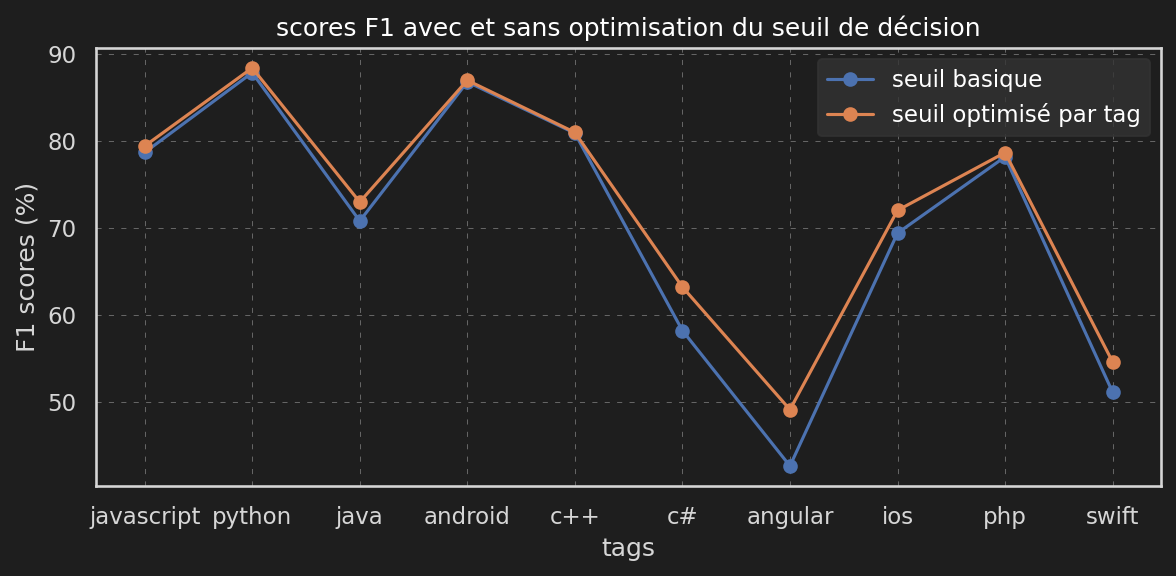

In [31]:
funcs.plot_f1_scores(results,
                     prediction_tags,
                     'avec et sans optimisation du seuil de décision',
                     'decision_threshold')

Les résultats sont améliorés en optimisant le seuil de décision par tag.

## Longueur du vocabulaire

In [32]:
results = {}
for max_features in [300, 600, 900, 1200]:
    tmp = funcs.Vectorised()
    tmp.initialize_data('tfidf',
                           funcs.concat_str_features(x_train, features),
                           y_train,
                           min_df=100, max_df=0.95, max_features=max_features
                           )
    tmp.set('test', funcs.concat_str_features(x_test, features))
    t0 = time.time()
    tmp.train_classifier(model)
    tmp.optimize_threshold()
    print(f'max fatures : {max_features}, elapsed time: {time.time()-t0:.2f} sec.')

    y_pred = tmp.predict_optim_threshold('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()
    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    n_features = len(tmp.get_vocabulary())
    results[n_features] = df_res.iloc[-1,:]

vocaublary length: 300


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 300, elapsed time: 38.69 sec.
vocaublary length: 600


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 600, elapsed time: 60.88 sec.
vocaublary length: 900


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 900, elapsed time: 89.73 sec.
vocaublary length: 1200


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 1200, elapsed time: 114.45 sec.


In [33]:
filename = 'data/results/vobaculary_length'
if False:
    with open(filename, 'wb') as file:
        pickle.dump(results, file)
else:
    with open(filename, 'rb') as file:
        results = pickle.load(file)
del filename

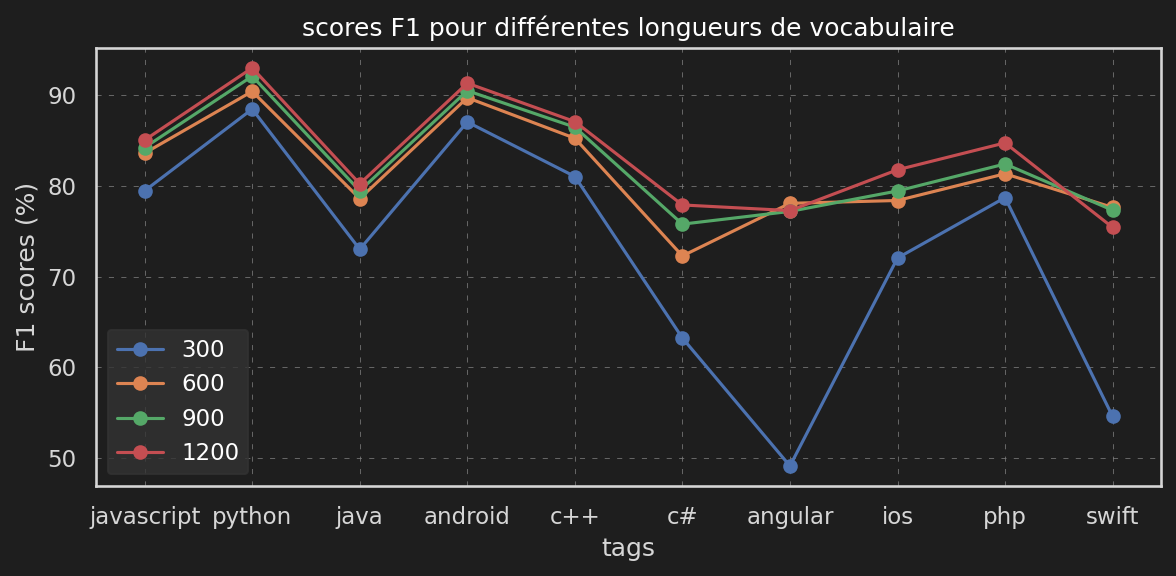

In [34]:
funcs.plot_f1_scores(results, prediction_tags,
                     'pour différentes longueurs de vocabulaire',
                     'vocab_length')

Augmenter le nombre de mots du covabulaire améliore les résultats, avec une limite à 900, ici, pour swift.

Pour la suite, les essais sont effectué avec 900 mots.

In [35]:
importlib.reload(funcs)
vectorised = funcs.Vectorised()
vectorised.initialize_data('tfidf',
                        funcs.concat_str_features(x_train, features),
                        y_train,
                        min_df=100, max_df=0.95, max_features=900
                        )
vectorised.set('test', funcs.concat_str_features(x_test, features))

vocaublary length: 900


## Optimisation des hyper paramètres

In [36]:
importlib.reload(funcs)
results = {}
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    tmp = funcs.Vectorised()
    tmp.copy_data_from_vetorizer(vectorised)
    t0 = time.time()
    tmp.train_classifier(model, kernel_params={'C':C})
    tmp.optimize_threshold()
    print('C: {:}, elapsed time: {:.2f} seconds'.format(C, time.time()-t0))

    y_pred = tmp.predict_optim_threshold('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()

    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    display(df_res)
    results[C] = df_res.iloc[-1, :]

C: 0.01, elapsed time: 55.52 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,85.34,93.55,83.04,92.60,88.02,75.23,79.67,83.26,87.72,82.09
recall,82.92,89.83,75.76,86.58,84.39,75.63,77.06,75.74,77.43,73.46
specificity,97.29,98.96,97.10,99.06,98.05,95.67,99.56,98.89,99.21,99.51
F1 score,84.11,91.65,79.23,89.49,86.17,75.43,78.34,79.32,82.25,77.53


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

C: 0.1, elapsed time: 91.16 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.56,93.87,83.70,93.84,88.79,78.11,78.16,79.21,87.86,79.34
recall,83.82,90.13,75.61,87.03,84.29,73.66,76.22,79.65,77.68,74.90
specificity,97.09,99.01,97.24,99.23,98.20,96.41,99.52,98.47,99.21,99.41
F1 score,84.19,91.96,79.45,90.31,86.48,75.82,77.17,79.43,82.46,77.06


...

C: 100, elapsed time: 95.90 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.46,95.01,83.56,94.17,89.06,78.50,80.68,80.59,86.55,81.67
recall,83.93,89.26,75.69,87.04,84.06,73.21,73.94,78.28,78.59,73.34
specificity,97.06,99.21,97.21,99.27,98.25,96.51,99.60,98.62,99.11,99.50
F1 score,84.20,92.05,79.43,90.46,86.49,75.76,77.16,79.42,82.38,77.28


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

C: 1000, elapsed time: 95.65 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.45,95.00,83.56,94.17,89.06,78.50,80.68,80.59,86.55,81.71
recall,83.93,89.26,75.69,87.04,84.06,73.22,73.94,78.30,78.59,73.34
specificity,97.06,99.21,97.21,99.27,98.25,96.51,99.60,98.62,99.11,99.50
F1 score,84.19,92.04,79.43,90.46,86.49,75.77,77.16,79.43,82.38,77.30


In [37]:
filename = 'regularisation'
if False:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(results, file)
else:
    with open(path_results + filename, 'rb') as file:
        results = pickle.load(file)
del filename

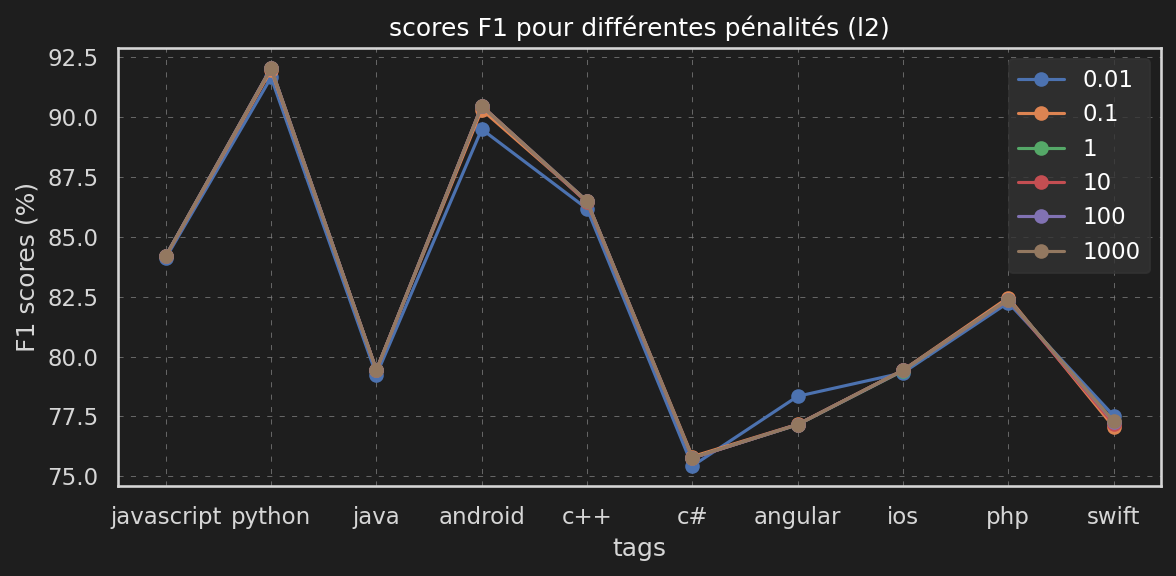

In [38]:
funcs.plot_f1_scores(results, prediction_tags,
                     'pour différentes pénalités (l2)',
                     'regularisation')

## Extra Trees

Temps de calcul pour une forêt : 33 minutes pour 1 configuration.
* pour ce projet, on ce modèle n'est pas exploré
* dans un cadre industriel, le modèle peut être calculé en passant sur un calculateur, en fonction des possibilités du client
* il est aussi possible d'essayer la fonction RandomizeSeachCV du module sklearn

In [9]:
param_grid = {
              'max_depth': [None],#, 5, 10],
              'max_features':['sqrt', 'log2', None],
              'min_samples_split': [2], #, 4],
              'min_samples_leaf': [1], #, 4],
}

importlib.reload(funcs)
trees = funcs.train_extra_trees(vectorised, param_grid)

x_train: (86627, 900)
y_train: (86627, 10)
x_train: (86627, 900)
y_train: (86627, 10)
best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
if True:
    with open('data/models/trees.pickle', 'wb') as file:
        pickle.dump(trees, file)
else:
    with open('data/models/trees.pickle', 'rb') as file:
        trees = pickle.load(file)

In [11]:
y_pred = trees.predict(vectorised.scale(vectorised.get('test')))
y_true = y_test.values
prediction_tags = vectorised.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,93.78,98.62,97.14,98.79,97.18,95.83,96.32,90.06,97.98,93.90
recall,69.86,81.57,57.64,70.77,69.29,39.70,28.79,51.27,55.38,44.39
specificity,99.10,99.81,99.69,99.88,99.66,99.70,99.97,99.59,99.92,99.91
F1 score,80.07,89.29,72.35,82.46,80.90,56.15,44.32,65.34,70.76,60.29


In [12]:
filename = 'data/results/trees.pickle'
with open(filename, 'wb') as file:
    pickle.dump(df_res, file)

## méthodes "Deep Learning"

### Word2Vect

La méthode est limitée par le fait qu'elle prend en compte chaque mot séparément.

In [13]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('word2vec',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

In [14]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 103.38 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,71.35,77.26,65.29,78.04,80.55,56.54,64.18,64.58,68.02,61.71
recall,70.77,75.27,65.08,72.80,76.80,61.92,58.37,63.73,61.81,57.48
specificity,94.48,96.31,93.57,97.26,96.84,91.76,99.23,97.48,97.89,98.91
F1 score,71.06,76.26,65.19,75.32,78.63,59.11,61.14,64.15,64.77,59.52


In [15]:
filename = 'data/results/w2v.pickle'
with open(filename, 'wb') as file:
    pickle.dump(df_res, file)

### SBERT

In [17]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('sbert',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

In [18]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values
prediction_tags = tmp.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 105.53 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,89.16,97.23,88.01,94.43,93.64,88.11,87.86,85.10,92.82,80.66
recall,88.94,93.57,81.13,91.45,89.71,82.59,85.76,89.78,88.01,70.99
specificity,97.90,99.56,97.95,99.28,98.96,98.07,99.72,98.87,99.50,99.48
F1 score,89.05,95.37,84.43,92.91,91.63,85.26,86.80,87.38,90.35,75.52


In [20]:
filename = 'SBERT.pickle'

if True:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        pickle.dump(tmp.__dict__, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp = funcs.Vectorised()
        tmp.copy_data_from_dict(dict_tmp)

# filename = 'SBERT_x.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.get('train'), tmp.get('test')), file)
# filename = 'data/models/SBERT_y.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.y_train, y_test), file)

In [7]:
importlib.reload(funcs)

# filename = 'data/results/SBERT.pickle'
# with open(filename, 'rb') as file:
#     df_res_tmp = pickle.load(file)

# display(df_res_tmp)

# y_pred = tmp.predict_optim_threshold('test')
# df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
# display(df_res)

<module 'funcs' from '/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/funcs.py'>

In [8]:
features = ['Title_clean', 'Body_clean']

In [9]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('sbert',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

SBERT vectorization:
100.00%    

SBERT vectorization:
100.00%    



In [10]:
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 103.46 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.27,97.48,88.90,94.63,94.36,91.54,89.61,86.92,94.60,81.51
recall,90.72,96.16,82.59,92.36,92.82,86.29,87.51,88.55,92.13,76.91
specificity,98.10,99.59,98.08,99.30,99.05,98.62,99.76,99.04,99.62,99.47
F1 score,90.49,96.82,85.62,93.48,93.58,88.84,88.55,87.73,93.35,79.14


In [17]:
filename = 'SBERT_on_clean.pickle'

if False:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        pickle.dump(tmp.__dict__, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp2 = funcs.Vectorised()
        tmp2.copy_data_from_dict(dict_tmp)
        
        y_pred = tmp2.predict_optim_threshold('test')
        y_true = y_test.values
        prediction_tags = tmp2.get_prediction_tags()

        df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
        display(df_res)

# filename = 'SBERT_x.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.get('train'), tmp.get('test')), file)
# filename = 'data/models/SBERT_y.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.y_train, y_test), file)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.27,97.48,88.90,94.63,94.36,91.54,89.61,86.92,94.60,81.51
recall,90.72,96.16,82.59,92.36,92.82,86.29,87.51,88.55,92.13,76.91
specificity,98.10,99.59,98.08,99.30,99.05,98.62,99.76,99.04,99.62,99.47
F1 score,90.49,96.82,85.62,93.48,93.58,88.84,88.55,87.73,93.35,79.14


### Universal Sentence Encoder

In [19]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('use',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

2023-05-08 17:22:09.686432: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype string
	 [[{{node inputs}}]]


USE vectorization:
100.00%    

USE vectorization:
100.00%    



In [20]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


elapsed time: 97.06 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,86.60,94.56,89.21,93.53,91.81,88.10,80.67,87.34,92.40,73.35
recall,86.07,91.77,79.81,89.71,89.23,84.44,78.41,84.79,87.79,71.69
specificity,97.41,99.12,98.21,99.17,98.64,98.03,99.56,99.11,99.47,99.20
F1 score,86.33,93.14,84.25,91.58,90.50,86.23,79.52,86.04,90.04,72.51


In [23]:
filename = 'USE.pickle'

if True:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        tmp_dict = tmp.__dict__
        tmp_dict.pop('vectorizer')
        pickle.dump(tmp_dict, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp = funcs.Vectorised()
        tmp.copy_data_from_dict(dict_tmp)
        # ! AJOUT VECTORIZER

### Conclusions

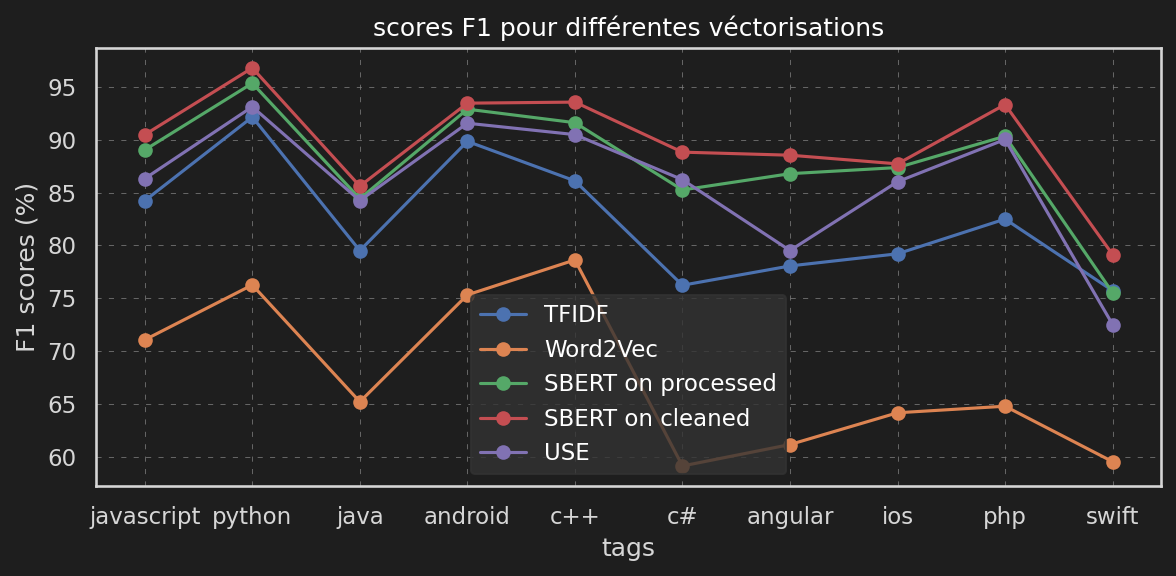

In [25]:
df_res = {}
with open(path_results + 'regularisation', 'rb') as file:
    df_res['TFIDF'] = pickle.load(file)[1]

with open(path_results + 'w2v.pickle', 'rb') as file:
    df_res['Word2Vec'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'SBERT.pickle', 'rb') as file:
    df_res['SBERT on processed'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'SBERT_on_clean.pickle', 'rb') as file:
    df_res['SBERT on cleaned'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'USE.pickle', 'rb') as file:
    df_res['USE'] = pickle.load(file).iloc[-1,:]

funcs.plot_f1_scores(df_res, vectorised.get_prediction_tags(),
                     'pour différentes véctorisations',
                     'vectorizer')

## Sauvegarde du modèle

In [39]:
filename = 'SBERT_on_clean.pickle'

with open(path_models + filename, 'rb') as file:
    dict_tmp = pickle.load(file)

print(dict_tmp.keys())
variables = ['scaler', 'clf', 'optimized_thresholds', 'method',
             'b_scale_x', 'use_pca']
out = {var:dict_tmp[var] for var in variables}
out['prediction tags'] = prediction_tags.values

with open(path_models + 'final.pickle', 'wb') as file:
    pickle.dump(out, file)

dict_keys(['x', 'scaler', 'b_scale_x', 'clf', 'optimized_thresholds', 'pca', 'use_pca', 'vectorizer', 'method', 'y_train'])


---